In [ ]:
from sklearn.model_selection import train_test_split
from sklearn import tree
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt


In [ ]:
df=pd.read_excel("data/Superstore-Excel-Analysis.xlsx")

: 

In [15]:
df["karli"]=(df["Profit"]>0).astype(int)
features=["Discount","Quantity","Category","Sub-Category","Region","Segment"]
x=df[features]
y=df["karli"]
x=pd.get_dummies(x,drop_first=True)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)

In [ ]:
model=DecisionTreeClassifier(criterion="gini",random_state=42)
model.fit(x_train,y_train)
y_tahmin=model.predict(x_test)
basari_orani=accuracy_score(y_test,y_tahmin)
print(f"Modelin Başarı Oranı: % {basari_orani * 100:.2f}")



Modelin Başarı Oranı: % 93.10


In [18]:
print(df["karli"].value_counts(normalize=True))

karli
1    0.806284
0    0.193716
Name: proportion, dtype: float64


In [21]:
print(confusion_matrix(y_test,y_tahmin))
print(classification_report(y_test,y_tahmin))

[[ 337   64]
 [  74 1524]]
              precision    recall  f1-score   support

           0       0.82      0.84      0.83       401
           1       0.96      0.95      0.96      1598

    accuracy                           0.93      1999
   macro avg       0.89      0.90      0.89      1999
weighted avg       0.93      0.93      0.93      1999



In [29]:
log_model=LogisticRegression(max_iter=1000)
log_model.fit(x_train,y_train)
log_pred=log_model.predict(x_test)
print(f"Logistic Regression %{accuracy_score(y_test,log_pred)*100:.2f}")

Logistic Regression %94.30


In [30]:
rf_model=RandomForestClassifier(n_estimators=100,random_state=42)
rf_model.fit(x_train,y_train)
rf_pred=rf_model.predict(x_test)
print(f"Random Forest %{accuracy_score(y_test,rf_pred)*100:.2f}")

Random Forest %93.35


In [31]:
importances=pd.DataFrame({
    "features":x_train.columns,
    "importances":rf_model.feature_importances_
}).sort_values("importances",ascending=False)

print(importances.head(10))

                    features  importances
0                   Discount     0.678239
1                   Quantity     0.092699
6       Sub-Category_Binders     0.028207
17      Sub-Category_Storage     0.022150
19       Sub-Category_Tables     0.021863
22               Region_West     0.018626
15        Sub-Category_Paper     0.018537
23         Segment_Corporate     0.012948
20               Region_East     0.012349
2   Category_Office Supplies     0.011162


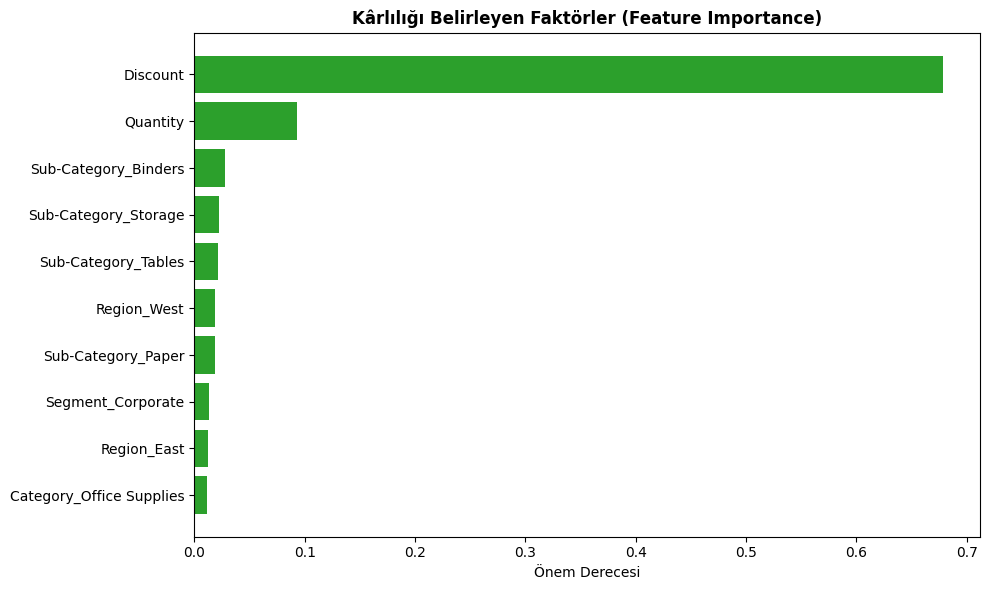

In [ ]:
top10=importances.head(10).sort_values("importances")
plt.figure(figsize=(10,6))
plt.barh(top10["features"],top10["importances"],color="#2ca02c")
plt.title("Kârlılığı Belirleyen Faktörler (Feature Importance)",fontweight="bold")
plt.xlabel("Önem Derecesi")
plt.tight_layout()
plt.savefig("/images/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## Key Findings

### Model Karşılaştırması
| Model | Accuracy |
|-------|----------|
| Logistic Regression | %94.3 |
| Random Forest | %93.4 |
| Decision Tree | %93.0 |

- Üç model de %93-94 bandında benzer performans gösterdi.
- En basit model olan **Logistic Regression** en iyi sonucu verdi — bu, verideki ilişkilerin büyük ölçüde **doğrusal** olduğunu gösteriyor. Daha karmaşık model her zaman daha iyi değil.
- Veri dengesiz (%80.6 kârlı, %19.4 zararlı). Bu nedenle accuracy tek başına yeterli değil; zararlı sınıfın recall değeri (%84) iş açısından asıl önemli metrik — zararlı siparişlerin %84'ü önceden yakalanabiliyor.

### En Önemli Bulgu: İndirim
- **Discount, kârlılığı belirleyen 1 numaralı faktör** (önem derecesi 0.68 — diğer tüm değişkenlerin toplamından fazla).
- İkinci sırada Quantity (0.09), ardından zarar eden sub-category'ler (Tables, Storage) geliyor.
- Bu bulgu, daha önceki SQL ve Pandas analizlerini doğruluyor: yüksek indirim = düşük kârlılık.

### Aksiyon Önerisi
- İndirim politikası kârlılığın en kritik kaldıracı. %20 üzeri indirimler sıkı kontrol altına alınmalı.
- Model, bir sipariş gerçekleşmeden önce (indirim, miktar, kategori, bölge bilgisiyle) zararlı olma olasılığını tahmin edebilir — proaktif fiyatlandırma kontrolü için kullanılabilir.